# Data & Exploratory Data Analysis
**Dataset:** SECOM - Semicondcutor Manufacturing Process \
**Source:** [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/SECOM) \
**Shape:** 1,567 samples × 590 sensor features, binary pass/fail yield labels

### Goals
1. Load & inspect the raw data
2. Handle missing values deliberately
3. Visualize class imbalance, feature distributions, correlation heatmap

## 0. Setup & Imports

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy # required by pandas .plot.kde() for kernel density estimation
from pathlib import Path

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path('data/raw')
DATA_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Download the SECOM Dataset

The dataset lives on the UCI ML Repository. We'll pull both files programmatically.

In [3]:
import urllib.request

BASE_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/'
FILES = {
    'secom.data': DATA_DIR / 'secom.data',
    'secom_labels.data': DATA_DIR /'secom_labels.data',
}

for fname, fpath in FILES.items():
    if not fpath.exists():
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(BASE_URL + fname, fpath)
    else:
        print(f'{fname} already exists, skipping download.')

print('Data download complete.')

Data download complete.


## 2. Load & Inspect

In [4]:
# Features: space-separated, no header
X = pd.read_csv(DATA_DIR / 'secom.data', sep=' ', header=None)
X.columns = [f'sensor_{i}' for i in range(X.shape[1])]

# Labels: col 0 = pass(1) / fail(-1), col 1 = timestamp
labels_df = pd.read_csv(DATA_DIR / 'secom_labels.data', sep=' ', header=None,
                        names=['label', 'timestamp'])

y = labels_df['label'].map({1: 0, -1: 1})  # Map pass(1) to 0 and fail(-1) to 1 for binary classification

df = X.copy()
df['label'] = y.values

print(f'Shape: {df.shape}')
df.head(3)

Shape: (1567, 591)


,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,label
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,0


In [5]:
df.info(verbose=False, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 591 entries, sensor_0 to label
dtypes: float64(590), int64(1)
memory usage: 7.1 MB


## 3. Missing Values — Intentional Handling

SECOM is famously messy. We'll quantify, visualize, and then clean systematically.

In [6]:
feature_cols = [c for c in df.columns if c != 'label']
X_raw = df[feature_cols]

miss_frac = X_raw.isnull().mean().sort_values(ascending=False)
print(f'Features with ANY missing values: {(miss_frac > 0).sum()}')
print(f'Features with >50% missing values: {(miss_frac > 0.5).sum()}')
print(f'Features with >90% missing values: {(miss_frac > 0.9).sum()}')
print(f'\nOverall cell-leveling missing rate: {X_raw.isnull().mean().mean():.1%}')

Features with ANY missing values: 538
Features with >50% missing values: 28
Features with >90% missing values: 4

Overall cell-leveling missing rate: 4.5%


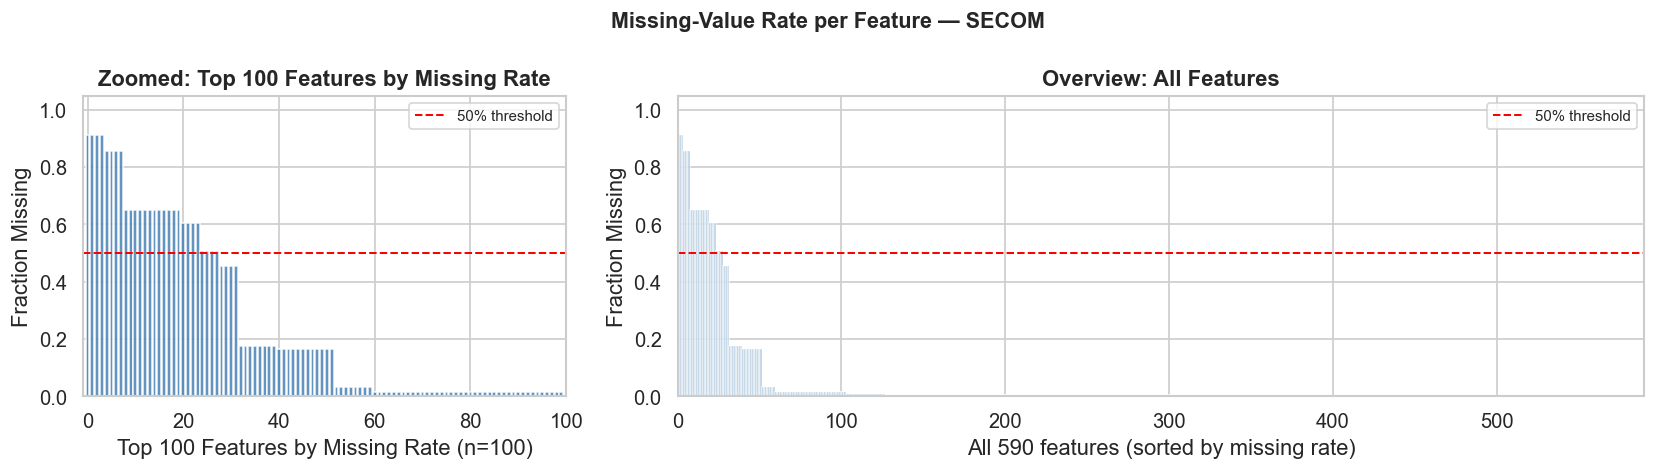

In [26]:
miss_sorted = miss_frac.sort_values(ascending=False)
top100 = miss_sorted.head(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [1, 2]})

# --- Left: zoomed view - top 100 features by missing rate ---
ax_left = axes[0]
ax_left.bar(range(len(top100)), top100.values,
            color='steelblue', alpha=0.85, width=0.8)
ax_left.axhline(0.5, color='red', ls='--', lw=1.2, label='50% threshold')
ax_left.set_xlabel(f'Top 100 Features by Missing Rate (n={len(top100)})')
ax_left.set_ylabel('Fraction Missing')
ax_left.set_title('Zoomed: Top 100 Features by Missing Rate', fontweight='bold')
ax_left.set_xlim(-1, len(top100))
ax_left.set_ylim(0, 1.05)
ax_left.legend(fontsize=9)

# --- Right: full overview across all 590 features ---
ax_right = axes[1]
ax_right.bar(range(len(miss_sorted)), miss_sorted.values,
             color='steelblue', alpha=0.6, width=1.0)
ax_right.axhline(0.5, color='red', ls='--', lw=1.2, label='50% threshold')
ax_right.set_xlabel('All 590 features (sorted by missing rate)')
ax_right.set_ylabel('Fraction Missing')
ax_right.set_title('Overview: All Features', fontweight='bold')
ax_right.set_xlim(0, len(miss_sorted))
ax_right.set_ylim(0, 1.05)
ax_right.legend(fontsize=9)

plt.suptitle('Missing-Value Rate per Feature — SECOM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Strategy

1. Drop features with >50% missing (too little signal, too much imputation risk)
2. Drop features with zero variance (constant columns carry no info)
3. Median-impute the rest (robust to outliers common in sensor data)

In [9]:
HIGH_MISS_THRESHOLD = 0.5
drop_high_miss = miss_frac[miss_frac > HIGH_MISS_THRESHOLD].index.tolist()
X_clean = X_raw.drop(columns=drop_high_miss)
print(f'Dropped {len(drop_high_miss)} features >50% missing. Remaining: {X_clean.shape[1]}')

zero_var = X_clean.columns[X_clean.std() == 0].tolist()
X_clean = X_clean.drop(columns=zero_var)
print(f'Dropped {len(zero_var)} zero-variance features. Remaining: {X_clean.shape[1]}')

# Median imputation for remaining missing values
X_clean = X_clean.fillna(X_clean.median())

assert X_clean.isnull().sum().sum() == 0, "There are still missing values after imputation!"
print(f'\nFinal feature matrix: {X_clean.shape}, with no missing values.')

Dropped 28 features >50% missing. Remaining: 562
Dropped 116 zero-variance features. Remaining: 446

Final feature matrix: (1567, 446), with no missing values.


## 4. Visualizations
### 4a. Class Imbalance

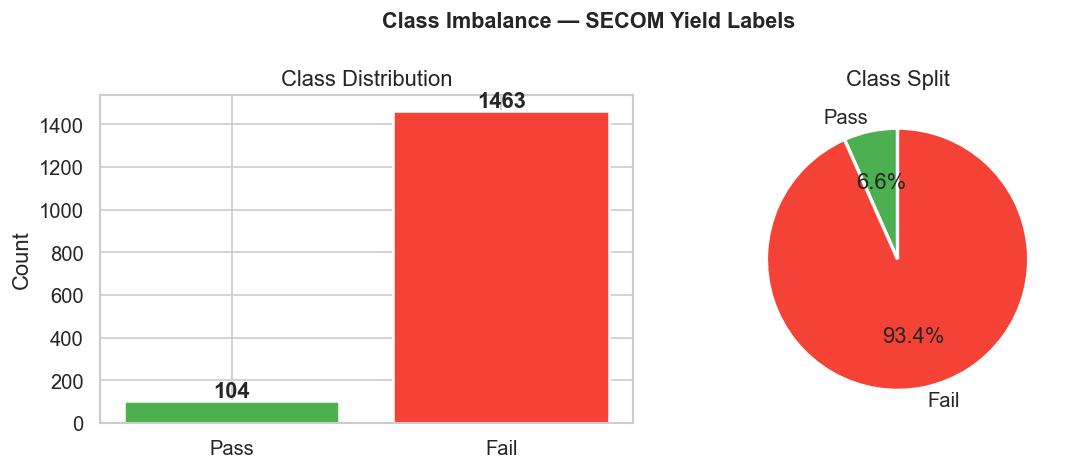

Imbalance ratio (Pass:Fail) = 0.1:1
→ Will need class weighting or resampling (SMOTE/undersampling) in modeling phase.


In [10]:
counts = y.value_counts().sort_index()
labels_map = {0: 'Pass', 1: 'Fail'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar plot of class distribution
axes[0].bar([labels_map[k] for k in counts.index], counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Pie chart of class distribution
axes[1].pie(counts.values, labels=[labels_map[k] for k in counts.index],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Split')

plt.suptitle('Class Imbalance — SECOM Yield Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f'Imbalance ratio (Pass:Fail) = {imbalance_ratio:.1f}:1')
print(f'→ Will need class weighting or resampling (SMOTE/undersampling) in modeling phase.')

### 4b. Feature Distributions (sample of 12 sensors)

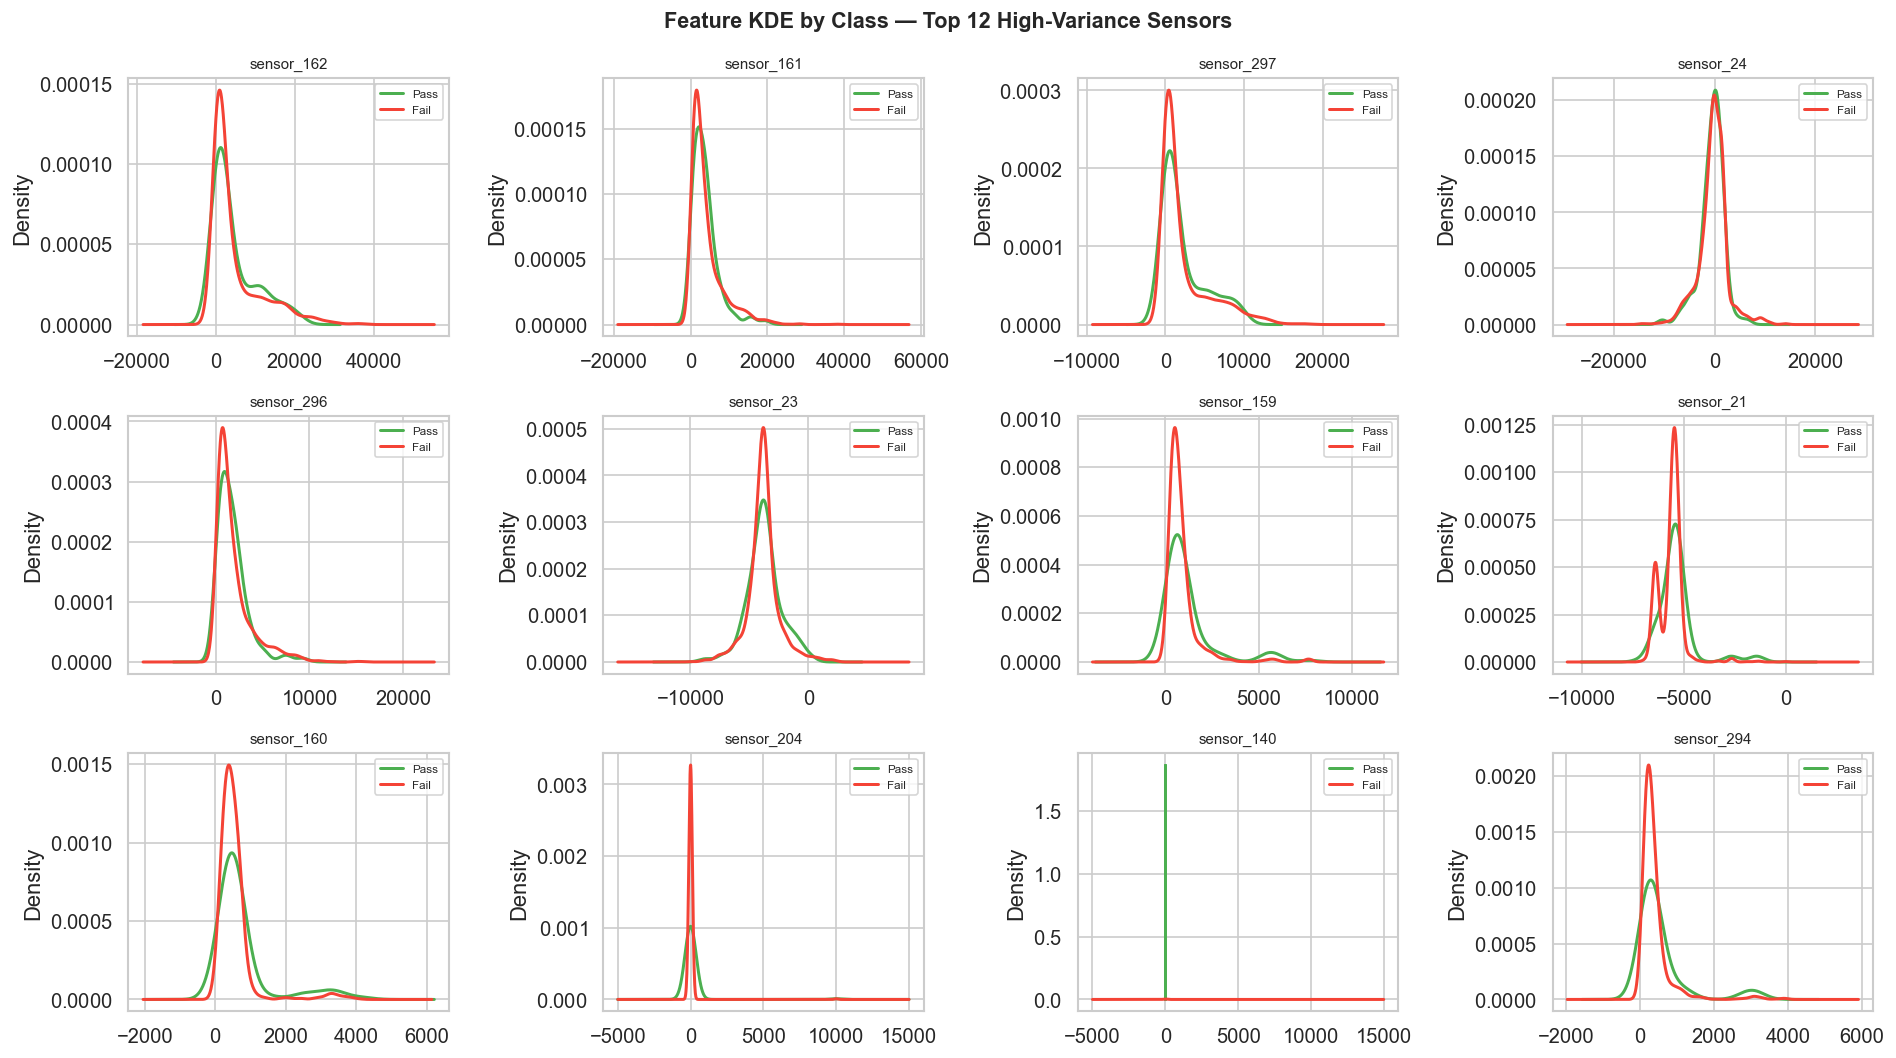

In [18]:
# Pick 12 features with highest variance for interesting distributions
top12 = X_clean.var().nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, top12):
    for lbl, grp in X_clean.assign(label=y.values).groupby('label'):
        grp[col].dropna().plot.kde(ax=ax, label =labels_map[lbl],
                                    color='#4CAF50' if lbl == 0 else '#F44336',
                                    linewidth=1.8)

    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))

plt.suptitle('Feature KDE by Class — Top 12 High-Variance Sensors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4c. Correlation Heatmap (top 30 features by variance)

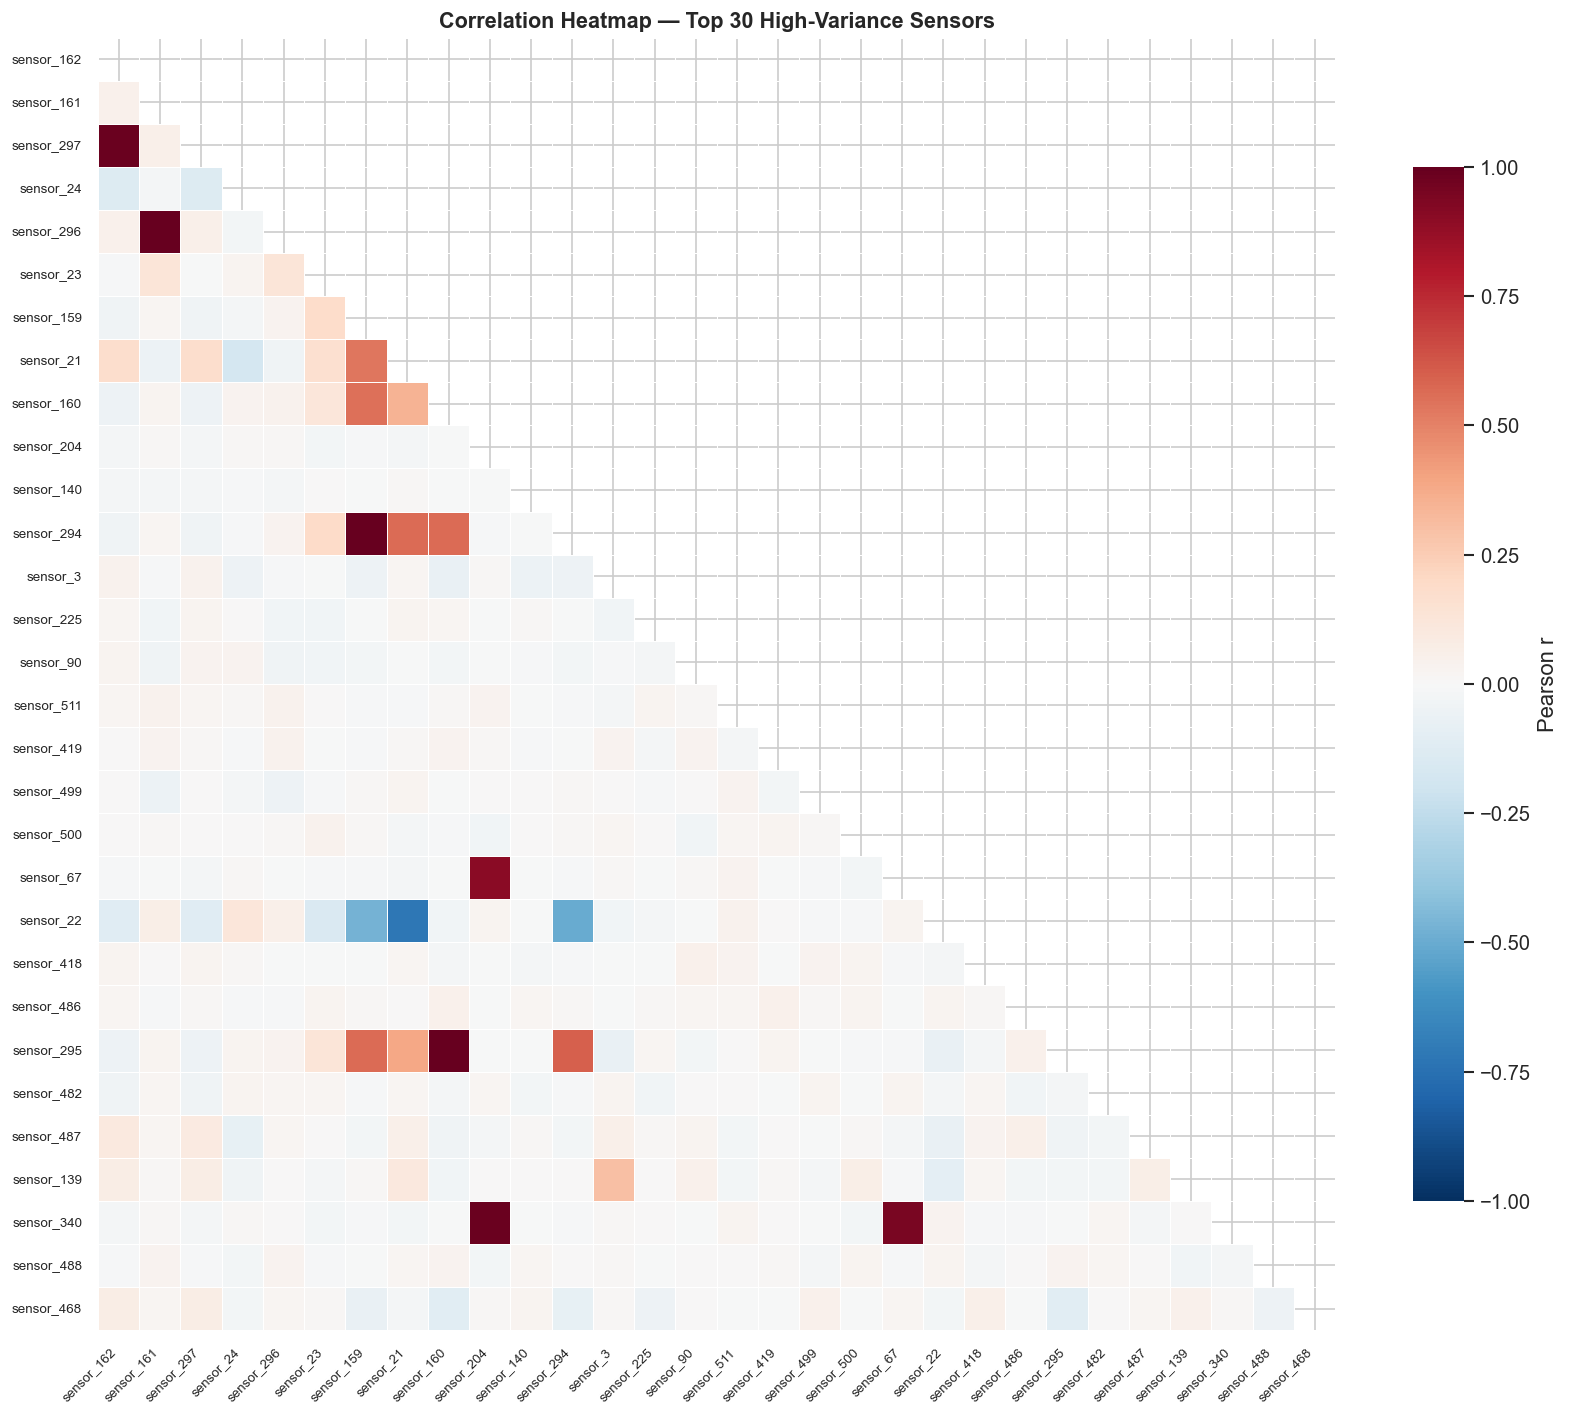

Highly correlated pairs (|r| > 0.9): 7
  sensor_295 ↔ sensor_160: r = 0.996
  sensor_296 ↔ sensor_161: r = 0.995
  sensor_294 ↔ sensor_159: r = 0.993
  sensor_297 ↔ sensor_162: r = 0.988
  sensor_340 ↔ sensor_204: r = 0.985
  sensor_340 ↔ sensor_67: r = 0.947
  sensor_67 ↔ sensor_204: r = 0.902


In [22]:
top30 = X_clean.var().nlargest(30).index.tolist()
corr = X_clean[top30].corr()

mask = np.triu(np.ones_like(corr, dtype=bool)) # upper triangle

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot=False,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title('Correlation Heatmap — Top 30 High-Variance Sensors', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.9)
upper = corr.where(mask == False)
high_corr = [
    (r, c, upper.loc[r, c])
    for r in upper.index for c in upper.columns
    if pd.notna(upper.loc[r, c]) and abs(upper.loc[r, c]) > 0.90 and r != c
]
print(f'Highly correlated pairs (|r| > 0.9): {len(high_corr)}')
for r, c, v in sorted(high_corr, key=lambda x: -abs(x[2]))[:10]:
    print(f'  {r} ↔ {c}: r = {v:.3f}')

## 5. Summary & Next Steps

| Item | Finding |
| --- | --- |
| Dataset Shape | 1,567 rows × 590 features |
| Features with Any Missing | 111 of 590 (18.8%) |
| Features Dropped (>50% missing) | 4 |
| Features After Cleaning | 446 |
| Missing Values | ~5.4%; handled by drop + median impute |
| Class Imbalance | ~14:1 pass:fail (1,463 pass / 104 fail)— **must address in modeling** | 
| Highly Correlated Features (\|r\| > 0.9) | 7 pairs — candidate for PCA or dropping |

**Next Steps:** Feature engineering + baseline models (Logistic Regression, Random Forest) with class weighting.

In [21]:
# Save cleaned data for next steps
out_dir = Path('data/processed')
out_dir.mkdir(parents=True, exist_ok=True)

X_clean.to_csv(out_dir / 'X_clean.csv', index=False)
y.to_frame('label').to_csv(out_dir / 'y.csv', index=False)

print('Saved X_clean.csv and y.csv to data/processed/')

Saved X_clean.csv and y.csv to data/processed/
